Search Algorithms for Drone Pathfinding
Setup and Imports

In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Abstract Problem Interface

In [3]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

Node Class, Search Result Class

In [4]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

Helper Functions

In [5]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

Implementation of Grid Search Problem

In [6]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        
        # Return True if state is equal to the goal state.
    
    
        if state == self.goal:
            return True
        else:
            return False
        

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        legal_actions = []
        for action,(dr,dc) in MOVES.items():
            next_state = (state[0] + dr, state[1] + dc)
            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)
        
        return legal_actions



    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
       
       self.state = state
       dr,dc = MOVES[action]
       next_state = (state[0] + dr,state[1] +dc)
       self.state = next_state
       return next_state
       

    def action_cost(self,state: Tuple[int, int],action: str,next_state: Tuple[int, int],) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        if self.in_bounds(next_state) and self.is_free(next_state):
            return 1
        else:
            return float('inf')
        

Self Check for GridProblem

In [7]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


A sample Drone Map

In [8]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

Visualization Helper

In [9]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

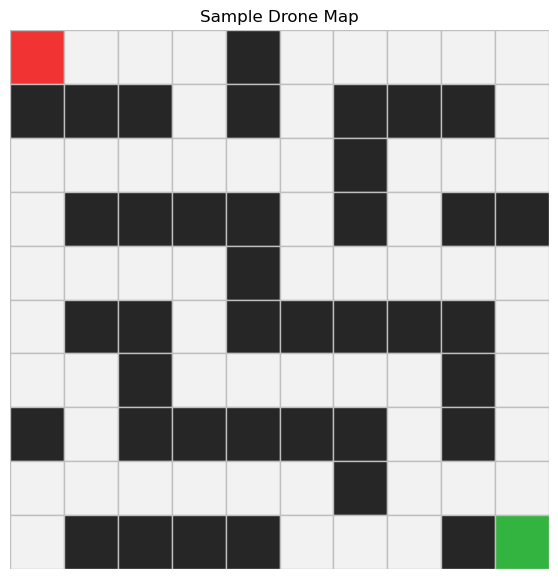

In [10]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

The Shared Expand Method

In [11]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
       
        st = node.state
        for action in problem.actions(st):
            s_prime = problem.result(st,action)
            cost = node.path_cost + problem.action_cost(st, action, s_prime)

            yield Node(state =s_prime,parent = node,action =action, path_cost =cost)
        
    

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

Breadth First Search

In [12]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        #Todo 6: Implement BFS graph search using a FIFO queue
        xy = problem.initial_state()
        if problem.is_goal(xy):
            return SearchResult(
                algorithm=algorithm, status= "success", solution = Node(state= xy),
                max_frontier_size= 1,nodes_expanded=0,
            )
        else:
            frontier =deque([Node(state=xy)])
            reached = {xy}
            nodes_expanded = 0
            max_frontier_size = 1

            while frontier:
                node = frontier.popleft()
                nodes_expanded += 1

                for child in self.expand(problem,node):
                    if problem.is_goal(child.state):
                        return SearchResult(
                        algorithm=algorithm,status= "success",solution =child,
                        nodes_expanded =nodes_expanded,
                        max_frontier_size = max_frontier_size,)
                    
                    if child.state not in reached:
                        reached.add(child.state)
                        frontier.append(child)

                max_frontier_size = max(max_frontier_size,len(frontier))

            return SearchResult(algorithm = algorithm,status ="failure",solution = None,
                                nodes_expanded=  nodes_expanded,max_frontier_size = max_frontier_size,)

        






Depth First Search

In [13]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self,problem : Problem)-> SearchResult:
        algorithm = "DFS"
        #Todo 7: Implement DFS graph search using a stack
        xy = problem.initial_state()
        if problem.is_goal(xy):
            return SearchResult(algorithm = algorithm,status = "success",solution = Node(state =xy),
                                nodes_expanded =0,max_frontier_size =1,)
        
        else:
            frontier = [Node(state =xy)]
            reached = {xy}
            nodes_expanded = 0
            max_frontier_size = 1

            while frontier:
                node = frontier.pop()
                nodes_expanded +=1

                for child in reversed(list(self.expand(problem,node))):
                    if problem.is_goal(child.state):
                        return SearchResult(algorithm=algorithm,status = "success",solution =child,
                                            nodes_expanded=nodes_expanded,max_frontier_size = max_frontier_size,
                                            )
                    
                    if child.state not in reached:
                        reached.add(child.state)
                        frontier.append(child)

                max_frontier_size = max(max_frontier_size,len(frontier))
            
            return SearchResult(algorithm=algorithm,satus = "failure",solution = None,
                                nodes_expanded =nodes_expanded,max_frontier_size=max_frontier_size,  )
        
                    
                        





Depth Limited Search

In [14]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self,problem: Problem,limit:int = 10)-> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {"nodes_expanded":0,"max_stack_size":1,}

        solution,status = self._recursive_dls(problem =problem,node = initial_node, limit = limit,metrics = metrics,
                                             current_stack_size =1,path = frozenset([problem.initial_state()]),)
        
        return SearchResult(algorithm =algorithm, status =status, solution =solution, nodes_expanded = metrics["nodes_expanded"],
                            max_frontier_size= metrics["max_stack_size"],reached_count =0,limit =limit,)
    

    def _recursive_dls(self, problem: Problem, node: Node, limit: int, metrics: Dict[str,int], current_stack_size: int, 
                       path= frozenset([problem.initial_state()]), ) -> Tuple[Optional [Node],str]:
        
#8. 
        xy= node.state
        if problem.is_goal(xy):
            return node, "success"
        elif node.depth >= limit:
            return None, "cutoff"
        else:
                metrics["nodes_expanded"] += 1
                cutoff_occurred = False

                for child in self.expand(problem,node):
                     if child.state in path:
                          continue
                     
                     current_stack_size += 1
                     metrics["max_stack_size"] = max(metrics["max_stack_size"],current_stack_size)

                     result, status = self._recursive_dls(problem = problem, node = child, limit = limit,metrics = metrics,
                                                         current_stack_size=current_stack_size,path = path | {child.state}, )
                     
                     current_stack_size -= 1 

                     if status  == "success" :
                          return result, "success"
                     elif status == "cutoff":
                          cutoff_occurred = True

                if cutoff_occurred:
                     return None, "cutoff"

                else:
                     return None,"failure"







Iterative Deepening Search

In [15]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # Todo 9. Implement IDS by repeatedly running DLS from limit 0 to max_depth.

        dls = DepthLimitedSearch()
        iteration_log = []
        total_nodes_expanded = 0
        for i in range(max_depth + 1):
            result = dls.search(problem, limit=i)
            iteration_log.append({
                "Limit": i,
                "Status": result.status,
                "Nodes expanded": result.nodes_expanded,
                "Max stack size": result.max_frontier_size,
            })
            total_nodes_expanded += result.nodes_expanded

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max(iteration["Max stack size"] for iteration in iteration_log),
                    reached_count=0,
                    limit=i,
                    iterations=iteration_log,
                )
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max(iteration["Max stack size"] for iteration in iteration_log),
                    reached_count=0,
                    limit=i,
                    iterations=iteration_log,
                )

Running Algorithms on Sample Map

In [16]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=20),
    ids.search(problem, max_depth=20),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18,18,50,5,0
1,DFS,success,NaN,26,26,37,4,0
2,DLS,success,20.0,18,18,63,21,0
3,IDS,success,18.0,18,18,356,19,0


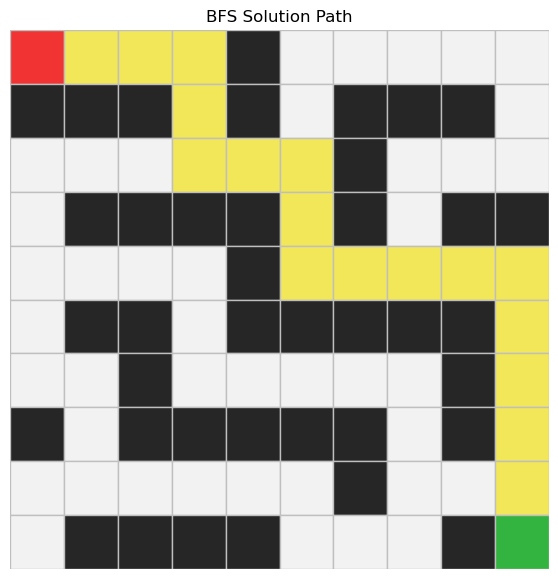

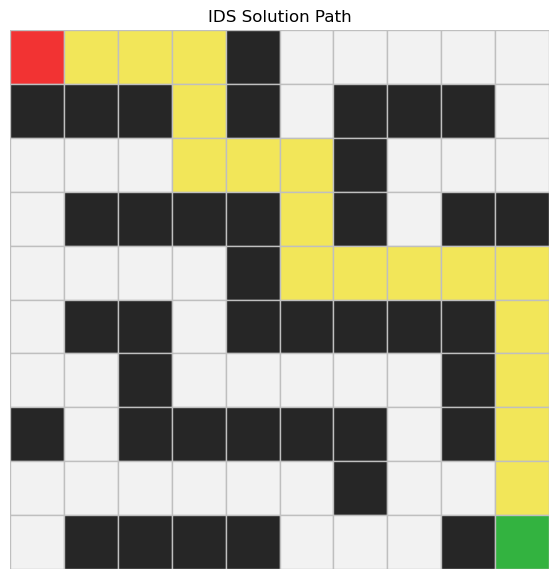

In [17]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

DLS_result = results[2]
IDS_result = results[3]

plot_path(
    sample_grid,
    start,
    goal,
    path=DLS_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=IDS_result.path,
    title="IDS Solution Path",
)

Creating your own map

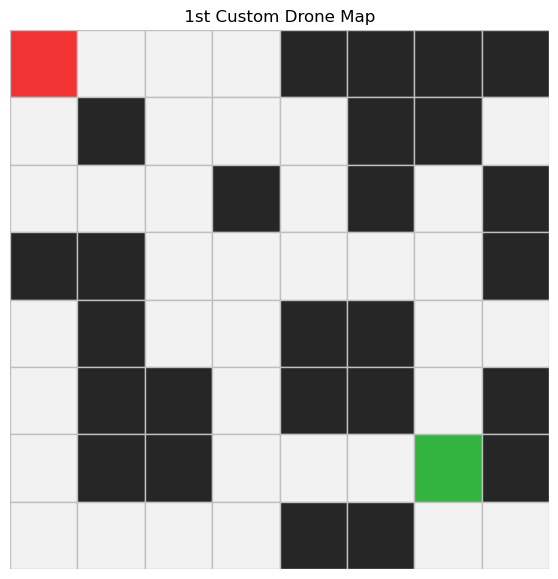

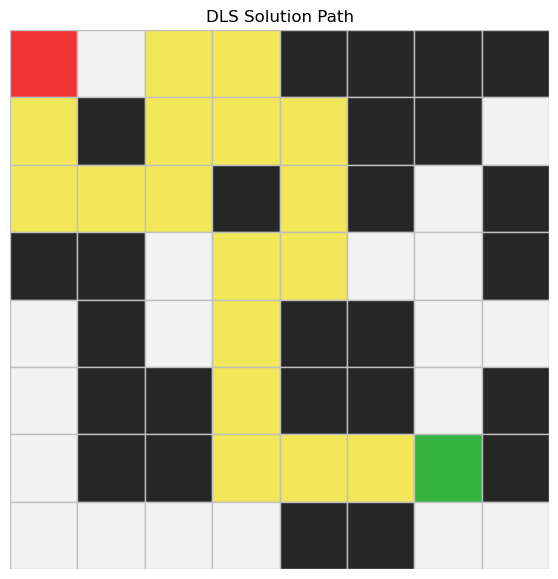

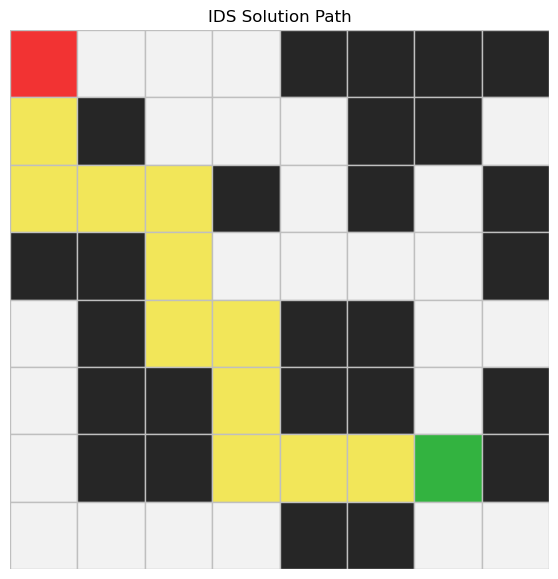

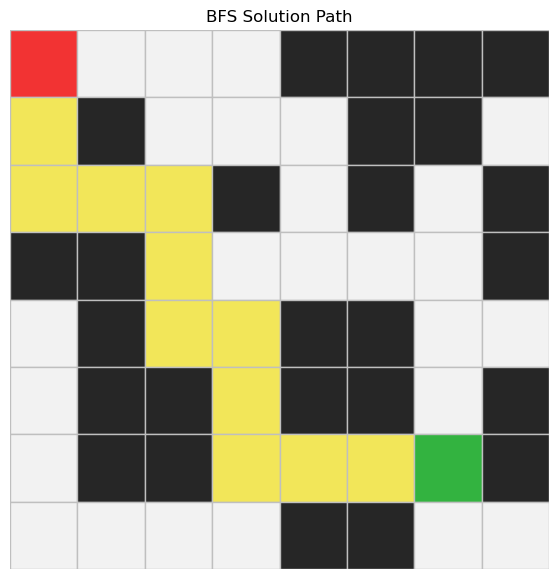

In [18]:
# TODO 10:
# Create your first custom map here.

my_grid = [
   [0,0,0,0,1,1,1,1],
   [0,1,0,0,0,1,1,0],
   [0,0,0,1,0,1,0,1],
   [1,1,0,0,0,0,0,1],
   [0,1,0,0,1,1,0,0],
   [0,1,1,0,1,1,0,1],
   [0,1,1,0,0,0,0,1],
   [0,0,0,0,1,1,0,0]
]

# testing a few path algorithms

my_start = (0,0)
my_goal = (6,6)

plot_path(my_grid, my_start, my_goal, title=" 1st Custom Drone Map ")

trial_problem = GridProblem(my_grid, my_start, my_goal)
trial_results = [
   bfs.search(trial_problem),
   dfs.search(trial_problem),
   dls.search(trial_problem, limit=20),
   ids.search(trial_problem, max_depth=40),
]
show_results(trial_results)

plot_path(
    my_grid,
    my_start,
    my_goal,
    path=trial_results[2].path,
    title="DLS Solution Path",
)

plot_path(
    my_grid,
    my_start,
    my_goal,
    path=trial_results[3].path,
    title="IDS Solution Path",)

plot_path(
  my_grid,
  my_start,
   my_goal,
   path=trial_results[0].path,
   title="BFS Solution Path",
)

# plot_path(
#    my_grid,
#   my_start,
#    my_goal,
#   path=trial_results[1].path,
#    title="DFS Solution Path",
# )

Second Map

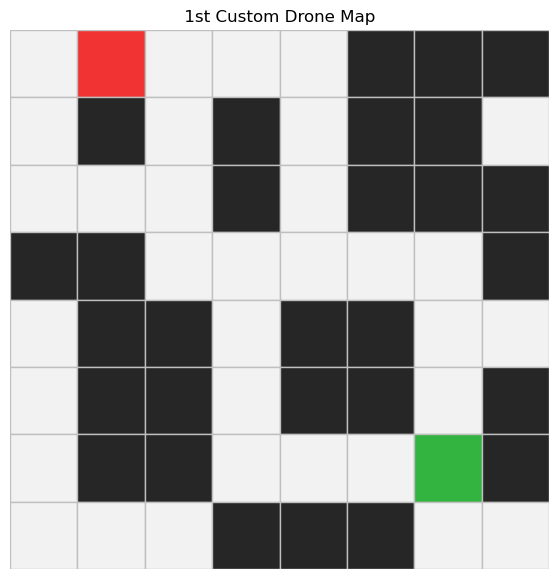

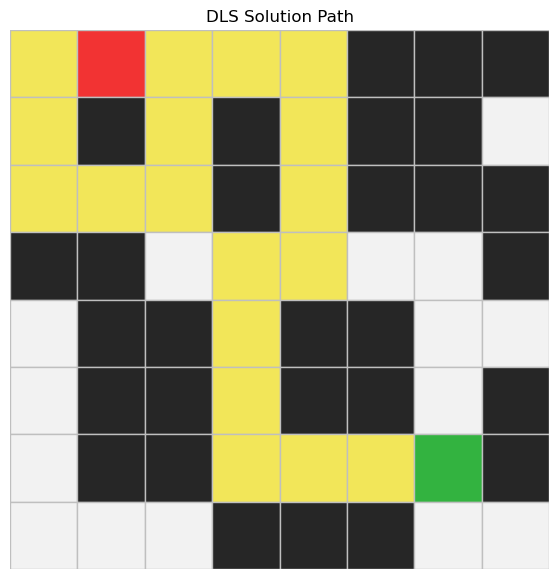

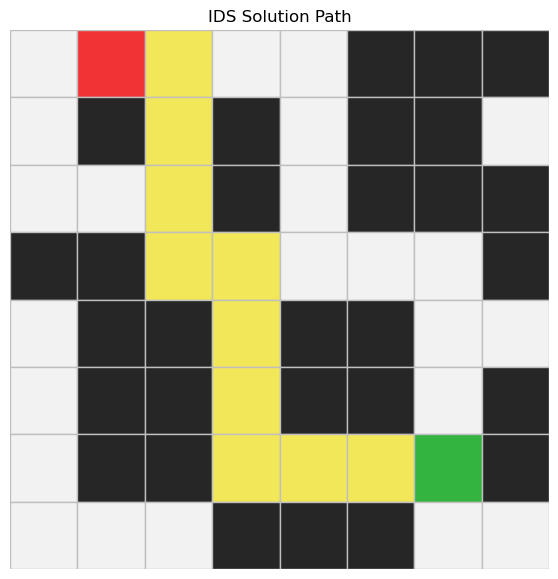

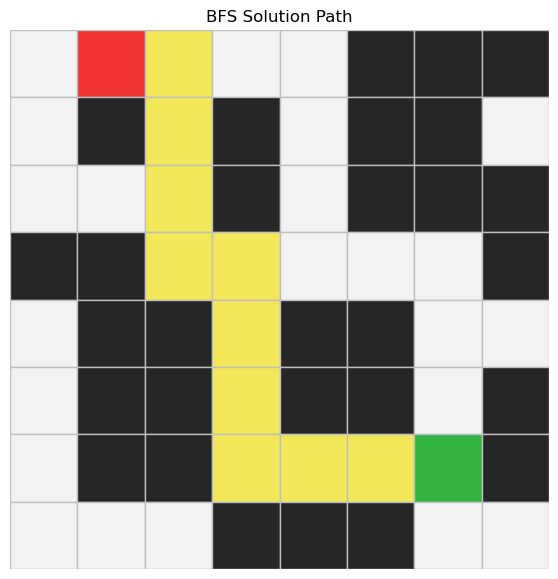

In [19]:

# Todo 11: Creating a second map


my_grid2 = [
   [0,0,0,0,0,1,1,1],
   [0,1,0,1,0,1,1,0],
   [0,0,0,1,0,1,1,1],
   [1,1,0,0,0,0,0,1],
   [0,1,1,0,1,1,0,0],
   [0,1,1,0,1,1,0,1],
   [0,1,1,0,0,0,0,1],
   [0,0,0,1,1,1,0,0]
]

# testing a few path algorithms

my_start2 = (0,1)
my_goal2 = (6,6)

plot_path(my_grid2, my_start2, my_goal2, title=" 1st Custom Drone Map ")

trial_problem2 = GridProblem(my_grid2, my_start2, my_goal2)
trial_results2 = [
   bfs.search(trial_problem2),
   dfs.search(trial_problem2),
   dls.search(trial_problem2, limit=20),
   ids.search(trial_problem2, max_depth=40),
]
show_results(trial_results2)

plot_path(
    my_grid2,
    my_start2,
    my_goal2,
    path=trial_results2[2].path,
    title="DLS Solution Path",
)

plot_path(
    my_grid2,
    my_start2,
    my_goal2,
    path=trial_results2[3].path,
    title="IDS Solution Path",)

plot_path(
  my_grid2,
  my_start2,
   my_goal2,
   path=trial_results2[0].path,
   title="BFS Solution Path",
)